<a href="https://colab.research.google.com/github/liangwan2023/MachineLearning/blob/main/MachineLearningAssignment5_SelectKBest%26Keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns



#load data and explore data
df = pd.read_csv("breast-cancer.csv")

print(df.head())
print(df.info())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [4]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [5]:
#malignant label to 1 and benign label to 0
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

In [6]:
# id is only a record number, so drop it before modeling
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']

In [8]:
# Correlation and SelectKBest can choose different features because they use different rules.
# Correlation ranks each feature by linear relationship with diagnosis.
# SelectKBest(f_classif) uses the ANOVA F-score to find the features
# that best separate the two diagnosis groups.

corr = df.drop(columns=['id']).corr()['diagnosis'].abs().sort_values(ascending=False)
corr_features = corr[1:7].index
print('Top 6 correlation features:')
print(corr_features)

selector = SelectKBest(score_func=f_classif, k=6)
selector.fit(X, y)
selected_features = X.columns[selector.get_support()]
feature_scores = pd.Series(selector.scores_, index=X.columns).sort_values(ascending=False)
print('\nTop 6 SelectKBest(f_classif) features:')
print(selected_features)
print('\nFeature scores:')
print(feature_scores.head(6))

# Use the SelectKBest features for the final neural-network model.
X = X[selected_features]

Top 6 correlation features:
Index(['concave points_worst', 'perimeter_worst', 'concave points_mean',
       'radius_worst', 'perimeter_mean', 'area_worst'],
      dtype='object')

Top 6 SelectKBest(f_classif) features:
Index(['perimeter_mean', 'concave points_mean', 'radius_worst',
       'perimeter_worst', 'area_worst', 'concave points_worst'],
      dtype='object')

Feature scores:
concave points_worst    964.385393
perimeter_worst         897.944219
concave points_mean     861.676020
radius_worst            860.781707
perimeter_mean          697.235272
area_worst              661.600206
dtype: float64


In [9]:
# Split first, then scale only from the training data to avoid leakage.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [10]:
# Check the split sizes and class balance.
print('Training shape:', X_train.shape)
print('Test shape:', X_test.shape)
print('Training class balance:')
print(y_train.value_counts(normalize=True))
print('\nTest class balance:')
print(y_test.value_counts(normalize=True))

Training shape: (455, 6)
Test shape: (114, 6)
Training class balance:
diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Test class balance:
diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


In [11]:
# convert for keras
X_train = np.asarray(X_train).astype("float32")
X_test = np.asarray(X_test).astype("float32")
y_train = np.asarray(y_train).astype("int32")
y_test = np.asarray(y_test).astype("int32")

# build model
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# train
history = model.fit(
    X_train, y_train,
    epochs=40,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 769 (3.00 KB)

 Trainable params: 769 (3.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - accuracy: 0.6868 - loss: 0.6413 - val_accuracy: 0.9011 - val_loss: 0.5069
Epoch 2/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9615 - loss: 0.4084 - val_accuracy: 0.8791 - val_loss: 0.3710
Epoch 3/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9615 - loss: 0.2848 - val_accuracy: 0.8791 - val_loss: 0.2970
Epoch 4/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9643 - loss: 0.2128 - val_accuracy: 0.8901 - val_loss: 0.2578
Epoch 5/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9615 - loss: 0.1692 - val_accuracy: 0.8681 - val_loss: 0.2423
Epoch 6/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9615 - loss: 0.1447 - val_accuracy: 0.8791 - val_loss: 0.2381
Epoch 7/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9615 - loss: 0.1306 - val_accuracy: 0.8681 - val_loss: 0.2377
Epoch 8/40
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9643 - loss: 0.1216 - val_accuracy: 0.8681 - val_lo

In [12]:
# takes unseen data (X_test)
# Predicts output for each row
# confusion_matrix(y_test, y_pred) compares actual vs predicted values
# accuracy_score(y_test, y_pred) measures overall correctness
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred)

print('Final selected features:')
print(selected_features)
print('\nConfusion matrix:')
print(cm)
print('\nClassification report:')
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
Final selected features:
Index(['perimeter_mean', 'concave points_mean', 'radius_worst',
       'perimeter_worst', 'area_worst', 'concave points_worst'],
      dtype='object')

Confusion matrix:
[[71  1]
 [ 2 40]]

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

Accuracy: 0.9736842105263158


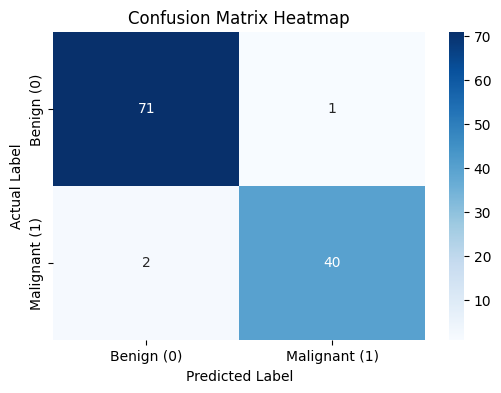

In [13]:
plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Benign (0)', 'Malignant (1)'],
    yticklabels=['Benign (0)', 'Malignant (1)']
)

plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix Heatmap')

plt.show()